# Sensitivity and Final Report

This notebook closes the interference and spillover workflow.

The analysis studied a recommendation setting where items compete for limited slate attention. A lower-ranked focal movie was randomly promoted in simulated MovieLens slates. That promotion helped the focal item, but it also shifted visibility away from other movies. The central question was not only whether the promoted item gained clicks, but whether the full slate gained value after accounting for displaced competitors.

This final notebook packages the work into portfolio-ready artifacts:

- final effect tables,
- direct, indirect, and total effect summaries,
- spillover sensitivity checks,
- advanced-model targeting results,
- limitations and recommendations,
- markdown writeups and resume bullets.

The main conclusion is that promoted-item gains alone are misleading under interference. In this simulation, the focal item gained engagement, but competitor losses more than offset that gain, producing a negative total slate effect.


## 1. Environment and Paths

This cell imports the tools used for final reporting and sets up the writeup folders. The notebook searches upward for the processed interference outputs so it can run from either JupyterLab or command-line execution.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "movielens_interference_observed_effects.csv").exists()
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

WRITEUP_DIR, FIGURE_DIR, TABLE_DIR


(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_4_interference_spillover_effects/writeup'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_4_interference_spillover_effects/writeup/figures'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_4_interference_spillover_effects/writeup/tables'))

The writeup folders keep final report artifacts colocated with the notebooks. Figures go into `writeup/figures`, tables go into `writeup/tables`, and markdown summaries go into the writeup root.


## 2. Load Final Inputs

This cell loads all outputs needed for the final report. These tables come from the earlier notebooks: setup, exposure mapping, randomized estimation, decomposition, and advanced modeling.


In [2]:
paths = {
    "setup_readiness": PROCESSED_DIR / "movielens_interference_setup_readiness.csv",
    "exposure_readiness": PROCESSED_DIR / "movielens_interference_exposure_readiness.csv",
    "observed_effects": PROCESSED_DIR / "movielens_interference_observed_effects.csv",
    "direct_indirect_total": PROCESSED_DIR / "movielens_interference_direct_indirect_total_effects.csv",
    "additivity_checks": PROCESSED_DIR / "movielens_interference_additivity_checks.csv",
    "spillover_sensitivity": PROCESSED_DIR / "movielens_interference_spillover_definition_sensitivity.csv",
    "product_summary": PROCESSED_DIR / "movielens_interference_product_summary.csv",
    "recommendations": PROCESSED_DIR / "movielens_interference_decomposition_recommendations.csv",
    "advanced_metrics": PROCESSED_DIR / "movielens_interference_advanced_model_metrics.csv",
    "advanced_aipw": PROCESSED_DIR / "movielens_interference_advanced_aipw_estimates.csv",
    "advanced_policy": PROCESSED_DIR / "movielens_interference_advanced_policy_targeting.csv",
    "advanced_takeaways": PROCESSED_DIR / "movielens_interference_advanced_takeaways.csv",
    "advanced_heterogeneity": PROCESSED_DIR / "movielens_interference_advanced_heterogeneity.csv",
    "cluster_risk": PROCESSED_DIR / "movielens_interference_cluster_risk.csv",
    "position_risk": PROCESSED_DIR / "movielens_interference_position_risk.csv",
}

loaded = {name: pd.read_csv(path) for name, path in paths.items()}

load_index = pd.DataFrame(
    {
        "artifact": list(paths.keys()),
        "path": [str(path) for path in paths.values()],
        "rows": [len(loaded[name]) for name in paths],
    }
)

display(load_index)


,artifact,path,rows
0,setup_readiness,/home/apex/Documents/ranking_sys/data/processe...,7
1,exposure_readiness,/home/apex/Documents/ranking_sys/data/processe...,8
2,observed_effects,/home/apex/Documents/ranking_sys/data/processe...,5
3,direct_indirect_total,/home/apex/Documents/ranking_sys/data/processe...,12
4,additivity_checks,/home/apex/Documents/ranking_sys/data/processe...,3
5,spillover_sensitivity,/home/apex/Documents/ranking_sys/data/processe...,5
6,product_summary,/home/apex/Documents/ranking_sys/data/processe...,5
7,recommendations,/home/apex/Documents/ranking_sys/data/processe...,4
8,advanced_metrics,/home/apex/Documents/ranking_sys/data/processe...,4
9,advanced_aipw,/home/apex/Documents/ranking_sys/data/processe...,3


The load index is a compact inventory of the full workflow. If a final table looks surprising, this index makes it easy to trace which upstream notebook produced the source data.


## 3. Build the Final Main Effects Table

This cell cleans the main randomized-estimator output. It converts estimates to report-friendly units and keeps the key quantities: direct focal effect, spillover effects, and total slate effect.


In [3]:
observed_effects = loaded["observed_effects"].copy()

final_effects = observed_effects[
    [
        "contrast",
        "outcome",
        "estimate",
        "cluster_se",
        "ci_95_lower",
        "ci_95_upper",
        "treated_mean",
        "control_mean",
        "treated_n",
        "control_n",
        "clusters",
    ]
].copy()
final_effects["estimate_per_1000"] = final_effects["estimate"] * 1000
final_effects["ci_95_lower_per_1000"] = final_effects["ci_95_lower"] * 1000
final_effects["ci_95_upper_per_1000"] = final_effects["ci_95_upper"] * 1000
final_effects["report_note"] = np.select(
    [
        final_effects["contrast"].eq("Direct focal item"),
        final_effects["contrast"].str.contains("spillover", case=False, na=False),
        final_effects["contrast"].eq("Total slate"),
    ],
    [
        "Promoted focal item gain.",
        "Competitor or non-focal item displacement.",
        "Net slate-level value after direct and spillover effects.",
    ],
    default="Supporting contrast.",
)

final_effects_output = TABLE_DIR / "final_main_effects.csv"
final_effects.to_csv(final_effects_output, index=False)

display(final_effects)


,contrast,outcome,estimate,cluster_se,ci_95_lower,ci_95_upper,treated_mean,control_mean,treated_n,control_n,clusters,estimate_per_1000,ci_95_lower_per_1000,ci_95_upper_per_1000,report_note
0,Direct focal item,Observed simulated click,0.1716,0.0157,0.1409,0.2023,0.3435,0.1719,1505,1495,3000,171.6152,140.9221,202.3083,Promoted focal item gain.
1,Same-cluster competitor spillover,Observed simulated click,-0.0577,0.0084,-0.0743,-0.0412,0.1522,0.2100,4309,4139,2456,-57.7146,-74.2530,-41.1761,Competitor or non-focal item displacement.
2,Displaced-item spillover,Observed simulated click,-0.0568,0.0057,-0.0679,-0.0457,0.1818,0.2386,11277,11133,3000,-56.7841,-67.8706,-45.6975,Competitor or non-focal item displacement.
3,All non-focal slate spillover,Observed simulated click,-0.0436,0.0046,-0.0526,-0.0346,0.1705,0.2141,16555,16445,3000,-43.5851,-52.6154,-34.5549,Competitor or non-focal item displacement.
4,Total slate,Observed total simulated clicks,-0.3078,0.0538,-0.4132,-0.2024,2.2193,2.5271,1505,1495,3000,-307.8212,-413.2036,-202.4388,Net slate-level value after direct and spillov...


This is the core result table. The focal item gains clicks, but the spillover rows are negative and the total slate effect is negative. That is the central evidence that item-level reporting would overstate product value.


## 4. Plot the Final Main Effects

This figure turns the main effects table into a clean final-report chart. It uses the original units for each contrast: item-level click-rate differences for item rows and total simulated clicks for the slate-level row.


/tmp/ipykernel_271007/2988254261.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


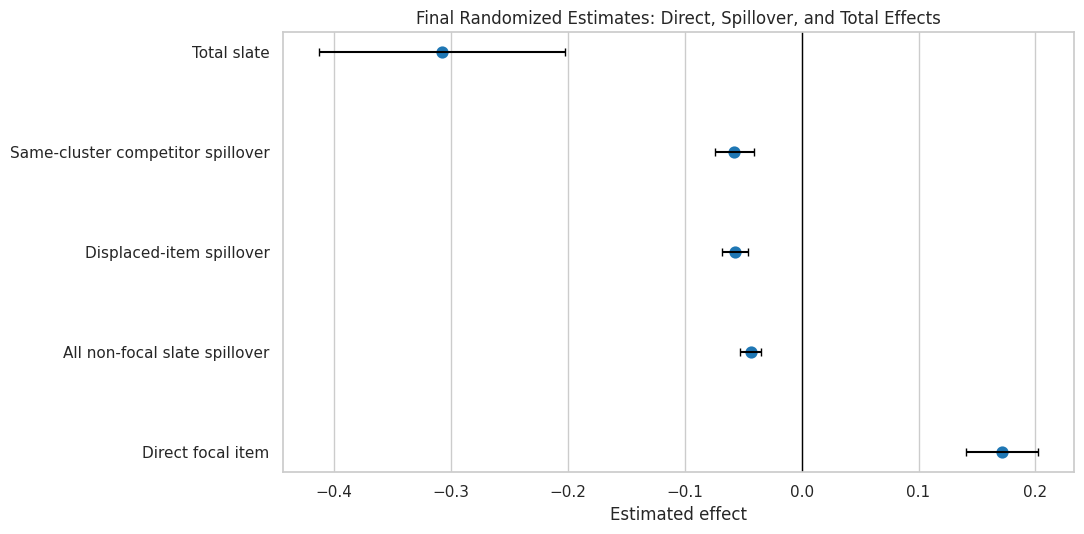

In [4]:
plot_effects = final_effects.sort_values("estimate").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.pointplot(
    data=plot_effects,
    x="estimate",
    y="contrast",
    join=False,
    errorbar=None,
    color="tab:blue",
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_effects.reset_index(drop=True).iterrows()):
    ax.errorbar(
        x=row["estimate"],
        y=y_pos,
        xerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="black",
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Randomized Estimates: Direct, Spillover, and Total Effects")
ax.set_xlabel("Estimated effect")
ax.set_ylabel("")
plt.tight_layout()
main_effects_figure = FIGURE_DIR / "25_final_main_effects.png"
fig.savefig(main_effects_figure, dpi=160, bbox_inches="tight")
plt.show()


The chart makes the contrast visible in one glance. The direct focal effect is positive, but every spillover contrast is negative and the net slate effect is negative. That is the practical signal that attention was reallocated rather than expanded.


## 5. Final Direct, Indirect, and Total Decomposition

This cell extracts the observed-click decomposition from the formal decomposition notebook. The table reports effects per promoted slate and per 1,000 promoted slates so the numbers can be used directly in a written summary.


In [5]:
decomposition = loaded["direct_indirect_total"].copy()
observed_decomposition = decomposition.query("outcome_type == 'observed_clicks'").copy()
observed_decomposition["component_label"] = observed_decomposition["effect_family"] + ": " + observed_decomposition["component"]

component_order = [
    "Direct: Focal item",
    "Indirect: Same-cluster competitors",
    "Indirect: Other competitors",
    "Total: Full slate",
]
observed_decomposition["component_order"] = observed_decomposition["component_label"].map(
    {label: i for i, label in enumerate(component_order)}
)
observed_decomposition = observed_decomposition.sort_values("component_order")

observed_decomposition_output = TABLE_DIR / "final_direct_indirect_total_decomposition.csv"
observed_decomposition.to_csv(observed_decomposition_output, index=False)

display(observed_decomposition[
    [
        "effect_family",
        "component",
        "estimate_per_slate",
        "ci_95_lower",
        "ci_95_upper",
        "estimate_per_1000_promoted_slates",
        "ci_95_lower_per_1000",
        "ci_95_upper_per_1000",
    ]
])


,effect_family,component,estimate_per_slate,ci_95_lower,ci_95_upper,estimate_per_1000_promoted_slates,ci_95_lower_per_1000,ci_95_upper_per_1000
0,Direct,Focal item,0.1716,0.1409,0.2023,171.6152,140.8990,202.3315
1,Indirect,Same-cluster competitors,-0.1454,-0.2015,-0.0892,-145.3905,-201.5497,-89.2313
2,Indirect,Other competitors,-0.3340,-0.4260,-0.2421,-334.0459,-425.9571,-242.1347
3,Total,Full slate,-0.3078,-0.4132,-0.2025,-307.8212,-413.1899,-202.4525


This decomposition is the most important final-report table. It shows the accounting: the direct focal gain is positive, but same-cluster and other-competitor losses combine into a larger negative indirect effect, so the full slate loses value.


## 6. Plot the Final Decomposition

This figure shows the same decomposition in clicks per 1,000 promoted slates. Positive bars are gains, negative bars are losses, and the total bar summarizes the net product effect.


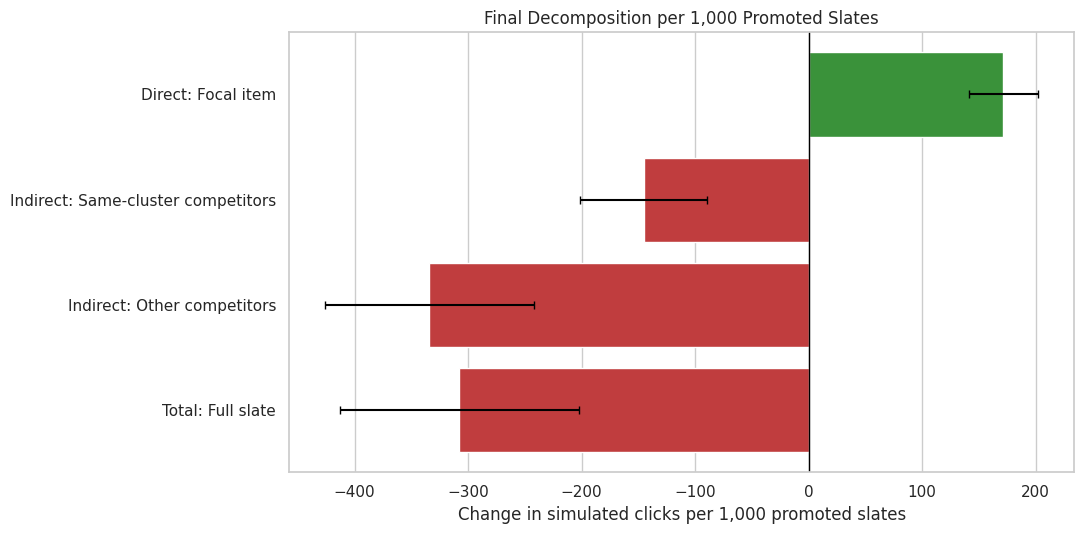

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["tab:green" if value >= 0 else "tab:red" for value in observed_decomposition["estimate_per_1000_promoted_slates"]]
sns.barplot(
    data=observed_decomposition,
    x="estimate_per_1000_promoted_slates",
    y="component_label",
    order=component_order,
    hue="component_label",
    palette=dict(zip(observed_decomposition["component_label"], colors)),
    legend=False,
    ax=ax,
)
for y_pos, (_, row) in enumerate(observed_decomposition.reset_index(drop=True).iterrows()):
    ax.errorbar(
        x=row["estimate_per_1000_promoted_slates"],
        y=y_pos,
        xerr=[
            [row["estimate_per_1000_promoted_slates"] - row["ci_95_lower_per_1000"]],
            [row["ci_95_upper_per_1000"] - row["estimate_per_1000_promoted_slates"]],
        ],
        fmt="none",
        color="black",
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Decomposition per 1,000 Promoted Slates")
ax.set_xlabel("Change in simulated clicks per 1,000 promoted slates")
ax.set_ylabel("")
plt.tight_layout()
decomposition_figure = FIGURE_DIR / "26_final_direct_indirect_total_decomposition.png"
fig.savefig(decomposition_figure, dpi=160, bbox_inches="tight")
plt.show()


The figure is the clearest final visual for the project. It shows why the promoted item's gain is not sufficient for product decision-making: the competitors lose more than the focal item gains.


## 7. Sensitivity Across Spillover Definitions

This cell packages the spillover sensitivity analysis. The goal is to check whether the spillover conclusion depends on one narrow definition of competition.


In [7]:
spillover_sensitivity = loaded["spillover_sensitivity"].copy()
spillover_sensitivity["estimate_per_1000_rows"] = spillover_sensitivity["estimate"] * 1000
spillover_sensitivity["ci_95_lower_per_1000_rows"] = spillover_sensitivity["ci_95_lower"] * 1000
spillover_sensitivity["ci_95_upper_per_1000_rows"] = spillover_sensitivity["ci_95_upper"] * 1000
spillover_sensitivity["direction"] = np.where(spillover_sensitivity["estimate"] < 0, "negative", "positive")

spillover_sensitivity_output = TABLE_DIR / "final_spillover_definition_sensitivity.csv"
spillover_sensitivity.to_csv(spillover_sensitivity_output, index=False)

display(spillover_sensitivity)


,definition,estimate,cluster_se,ci_95_lower,ci_95_upper,treated_mean,control_mean,treated_n,control_n,clusters,description,estimate_per_1000_rows,ci_95_lower_per_1000_rows,ci_95_upper_per_1000_rows,direction
0,All non-focal items,-0.0436,0.0046,-0.0526,-0.0346,0.1705,0.2141,16555,16445,3000,Every non-focal item in the slate.,-43.5851,-52.6154,-34.5549,negative
1,Same-cluster competitors,-0.0577,0.0084,-0.0743,-0.0412,0.1522,0.2100,4309,4139,2456,Non-focal items with the same primary-genre cl...,-57.7146,-74.2530,-41.1761,negative
2,Displaced items,-0.0568,0.0057,-0.0679,-0.0457,0.1818,0.2386,11277,11133,3000,Non-focal items above the focal item that shif...,-56.7841,-67.8706,-45.6975,negative
3,Same-cluster displaced substitutes,-0.0657,0.0104,-0.0860,-0.0454,0.1610,0.2268,2937,2809,2182,Same-cluster competitors that are also mechani...,-65.7224,-86.0311,-45.4137,negative
4,Near-position displaced items,-0.0330,0.0082,-0.0491,-0.0168,0.1604,0.1933,4515,4485,3000,Displaced items within three positions above t...,-32.9567,-49.1192,-16.7941,negative


Every tested spillover definition is negative in this simulation. That makes the displacement conclusion stronger: it is not just an artifact of using one particular competitor definition.


## 8. Plot Spillover Sensitivity

This figure compares spillover definitions with confidence intervals. It helps show which competitor definitions are broad and which are stricter.


/tmp/ipykernel_271007/4171360872.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


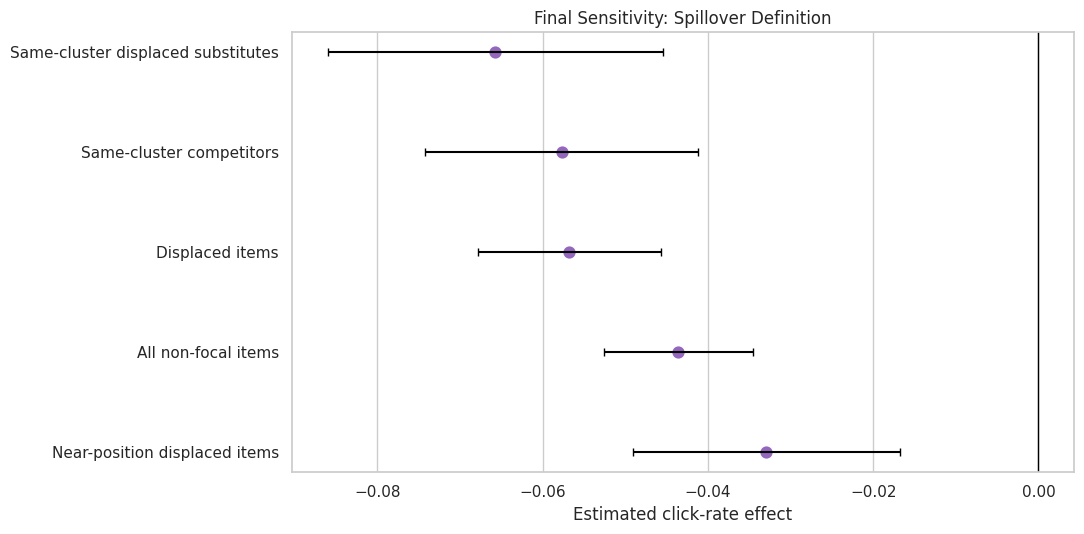

In [8]:
spillover_plot = spillover_sensitivity.sort_values("estimate").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.pointplot(
    data=spillover_plot,
    x="estimate",
    y="definition",
    join=False,
    errorbar=None,
    color="tab:purple",
    ax=ax,
)
for y_pos, (_, row) in enumerate(spillover_plot.reset_index(drop=True).iterrows()):
    ax.errorbar(
        x=row["estimate"],
        y=y_pos,
        xerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="black",
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Sensitivity: Spillover Definition")
ax.set_xlabel("Estimated click-rate effect")
ax.set_ylabel("")
plt.tight_layout()
spillover_figure = FIGURE_DIR / "27_final_spillover_sensitivity.png"
fig.savefig(spillover_figure, dpi=160, bbox_inches="tight")
plt.show()


The sensitivity figure supports a cautious but clear claim: under several plausible definitions of competitor exposure, spillover effects are negative. That gives the final recommendation more weight.


## 9. Advanced Modeling Summary

This cell packages the advanced modeling results: outcome-model metrics, model-assisted AIPW estimates, counterfactual targeting, and the final takeaways. These results show that flexible models can help target safer promotions, but they do not overturn the randomized finding.


In [9]:
advanced_metrics = loaded["advanced_metrics"].copy()
advanced_aipw = loaded["advanced_aipw"].copy()
advanced_policy = loaded["advanced_policy"].copy()
advanced_takeaways = loaded["advanced_takeaways"].copy()

advanced_summary = pd.concat(
    [
        advanced_takeaways.assign(section="takeaway"),
    ],
    ignore_index=True,
)

advanced_metrics.to_csv(TABLE_DIR / "final_advanced_model_metrics.csv", index=False)
advanced_aipw.to_csv(TABLE_DIR / "final_advanced_aipw_estimates.csv", index=False)
advanced_policy.to_csv(TABLE_DIR / "final_advanced_policy_targeting.csv", index=False)
advanced_takeaways.to_csv(TABLE_DIR / "final_advanced_takeaways.csv", index=False)

print("Advanced model metrics")
display(advanced_metrics)
print("Model-assisted estimates")
display(advanced_aipw)
print("Policy targeting")
display(advanced_policy)
print("Advanced takeaways")
display(advanced_takeaways)


Advanced model metrics


,model,split,rmse,mae,r2
0,LightGBM,train,0.8958,0.7144,0.6281
1,LightGBM,test,1.4425,1.1341,0.0813
2,XGBoost,train,1.1111,0.8913,0.4278
3,XGBoost,test,1.4054,1.1033,0.1280


Model-assisted estimates


,estimator,estimate,se,ci_95_lower,ci_95_upper,reference
0,Randomized difference in means,-0.3078,NaN,NaN,NaN,Observed total simulated clicks
1,Cross-fitted LightGBM AIPW,-0.3036,0.0505,-0.4024,-0.2047,Observed total simulated clicks
2,Oracle mean promotion lift,-0.3158,0.0019,-0.3195,-0.3120,Known simulation lift


Policy targeting


,policy,selected_slates,coverage,mean_predicted_lift_selected,mean_oracle_lift_selected,oracle_lift_per_1000_selected_slates,oracle_lift_per_1000_eligible_slates
0,Promote all eligible slates,3000,1.0000,-0.2388,-0.3158,-315.7549,-315.7549
1,Promote top 50% by predicted net lift,1500,0.5000,-0.1648,-0.3091,-309.0693,-154.5346
2,Promote top 25% by predicted net lift,750,0.2500,-0.1213,-0.3065,-306.4754,-76.6188
3,Promote only predicted-positive slates,30,0.0100,0.0901,-0.3654,-365.3709,-3.6537
4,Oracle top 25% benchmark,750,0.2500,-0.2284,-0.1953,-195.3376,-48.8344


Advanced takeaways


,area,finding,why_it_matters
0,Outcome modeling,XGBoost had the best held-out RMSE at 1.405 cl...,Flexible models can summarize how slate compos...
1,Conditional effects,XGBoost had CATE RMSE 0.161 versus the oracle ...,The model can be used to rank slates by predic...
2,Model-assisted estimation,Cross-fitted AIPW estimated -0.304 total click...,Model-assisted estimates should agree with the...
3,Policy targeting,The best evaluated policy was 'Promote only pr...,Targeting can reduce displacement harm compare...


The advanced-model story is nuanced. XGBoost had the best held-out prediction performance, and the model-assisted AIPW estimate closely matched the randomized estimator. Targeting reduced harm mainly by promoting fewer slates, which reinforces the product lesson: promotions should be gated by expected net slate value.


## 10. Plot Advanced Policy Targeting

This figure compares policy rules using oracle expected lift per 1,000 eligible slates. It rewards policies for selecting better slates but also accounts for how many slates they promote.


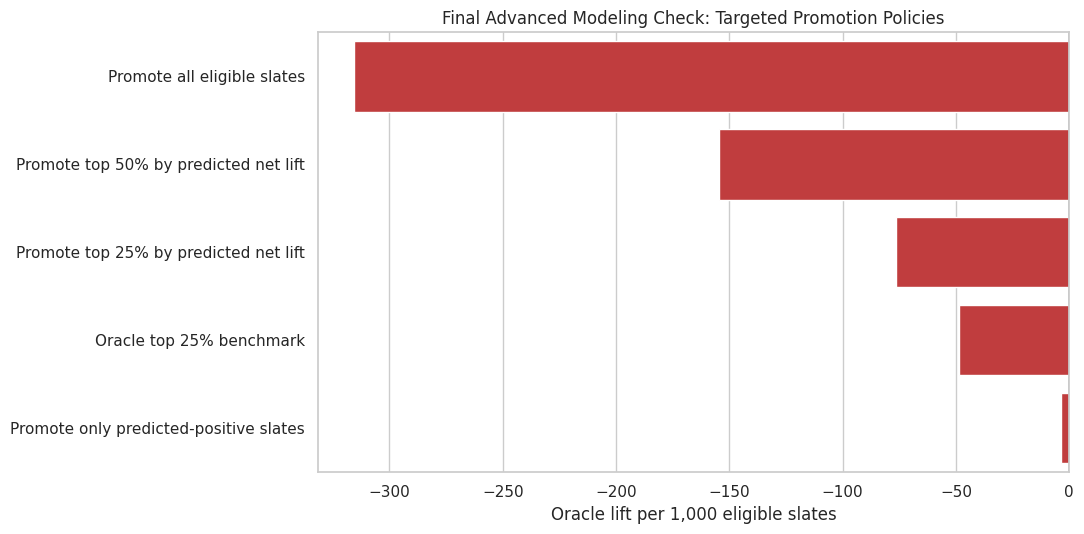

In [10]:
policy_plot = advanced_policy.sort_values("oracle_lift_per_1000_eligible_slates").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["tab:green" if value >= 0 else "tab:red" for value in policy_plot["oracle_lift_per_1000_eligible_slates"]]
sns.barplot(
    data=policy_plot,
    x="oracle_lift_per_1000_eligible_slates",
    y="policy",
    hue="policy",
    palette=dict(zip(policy_plot["policy"], colors)),
    legend=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Advanced Modeling Check: Targeted Promotion Policies")
ax.set_xlabel("Oracle lift per 1,000 eligible slates")
ax.set_ylabel("")
plt.tight_layout()
policy_figure = FIGURE_DIR / "28_final_policy_targeting.png"
fig.savefig(policy_figure, dpi=160, bbox_inches="tight")
plt.show()


The targeting figure shows that model-based selection can reduce harm compared with promoting every eligible slate. It also shows that the simulation contains few broadly positive promotion opportunities, so restraint is part of the recommended policy.


## 11. Limitations Table

This cell writes a limitations table. The project is methodologically useful, but the final report should be honest about the fact that MovieLens ratings are not real exposure logs and the promotion process is simulated.


In [11]:
limitations = pd.DataFrame(
    [
        {
            "limitation": "MovieLens contains ratings, not true recommendation impressions.",
            "impact": "The analysis demonstrates an interference workflow but does not estimate real production promotion effects.",
            "mitigation": "Use real slate impression logs or run a randomized slate experiment when available.",
        },
        {
            "limitation": "Promotion assignment and outcomes are simulated.",
            "impact": "The numerical estimates reflect the assumed data-generating process.",
            "mitigation": "Treat the results as a methodology demonstration and validate with online experiments.",
        },
        {
            "limitation": "Genres are coarse substitute clusters.",
            "impact": "Some substitutes may be missed and some same-genre items may not actually compete.",
            "mitigation": "Use learned item embeddings, co-watch patterns, or richer metadata for production analysis.",
        },
        {
            "limitation": "Only one promotion design is simulated.",
            "impact": "Different promotion probabilities, slate sizes, or ranking policies could change the net effect.",
            "mitigation": "Run sensitivity analyses over assignment rules and promotion intensities.",
        },
        {
            "limitation": "Advanced models are evaluated against simulated oracle lift.",
            "impact": "Policy targeting results depend on the simulated outcome mechanism.",
            "mitigation": "Use randomized or valid off-policy evaluation before deploying targeted promotion rules.",
        },
    ]
)

limitations_output = TABLE_DIR / "final_limitations.csv"
limitations.to_csv(limitations_output, index=False)
display(limitations)


,limitation,impact,mitigation
0,"MovieLens contains ratings, not true recommend...",The analysis demonstrates an interference work...,Use real slate impression logs or run a random...
1,Promotion assignment and outcomes are simulated.,The numerical estimates reflect the assumed da...,Treat the results as a methodology demonstrati...
2,Genres are coarse substitute clusters.,Some substitutes may be missed and some same-g...,"Use learned item embeddings, co-watch patterns..."
3,Only one promotion design is simulated.,"Different promotion probabilities, slate sizes...",Run sensitivity analyses over assignment rules...
4,Advanced models are evaluated against simulate...,Policy targeting results depend on the simulat...,Use randomized or valid off-policy evaluation ...


The limitations make the final report more credible. They separate the transferable causal workflow from the specific numeric simulation results, which should not be presented as real-world platform lift.


## 12. Final Recommendations

This cell combines the earlier decomposition recommendations with final-report wording. The recommendations are framed as decision rules for recommendation systems where items compete for attention.


In [12]:
recommendations = loaded["recommendations"].copy()
final_recommendations = pd.concat(
    [
        recommendations,
        pd.DataFrame(
            [
                {
                    "decision_area": "Experiment design",
                    "recommendation": "Randomize at the slate, cluster, or market level when interference is plausible.",
                    "evidence": "Item-level treatment assignment can miss displacement across neighboring items.",
                },
                {
                    "decision_area": "Advanced targeting",
                    "recommendation": "Use ML targeting only after validating net slate value against a randomized or off-policy benchmark.",
                    "evidence": "The model-assisted AIPW estimate matched the randomized estimate, while policy targeting mainly helped by avoiding many harmful promotions.",
                },
            ]
        ),
    ],
    ignore_index=True,
)

recommendations_output = TABLE_DIR / "final_recommendations.csv"
final_recommendations.to_csv(recommendations_output, index=False)
display(final_recommendations)


,decision_area,recommendation,evidence
0,Item-level reporting,Do not report promoted-item gain alone as the ...,"The focal item gains 171.6 clicks per 1,000 pr..."
1,Slate-level metric,Use total slate effect as the primary decision...,The net observed slate effect is -307.8 simula...
2,Spillover monitoring,Track same-cluster and displaced-item outcomes...,Competitor movement more than offsets the dire...
3,Policy design,Treat large rank jumps as higher-risk interven...,Promotion changes final positions for multiple...
4,Experiment design,"Randomize at the slate, cluster, or market lev...",Item-level treatment assignment can miss displ...
5,Advanced targeting,Use ML targeting only after validating net sla...,The model-assisted AIPW estimate matched the r...


The recommendations are deliberately operational. The final answer is not simply “promotion is bad.” The stronger lesson is that promotion decisions need slate-level metrics and spillover monitoring whenever items compete for scarce attention.


## 13. Final Executive Summary and Resume Bullets

This cell writes two markdown files: a final project summary and concise resume bullets. The summary is suitable for a portfolio writeup, while the bullets are written in a compact resume style.


In [13]:
direct_gain = final_effects.query("contrast == 'Direct focal item'")["estimate"].iloc[0]
total_effect = final_effects.query("contrast == 'Total slate'")["estimate"].iloc[0]
same_cluster_effect = final_effects.query("contrast == 'Same-cluster competitor spillover'")["estimate"].iloc[0]
all_non_focal_effect = final_effects.query("contrast == 'All non-focal slate spillover'")["estimate"].iloc[0]

direct_per_1000 = observed_decomposition.query("effect_family == 'Direct'")["estimate_per_1000_promoted_slates"].iloc[0]
same_cluster_per_1000 = observed_decomposition.query("component == 'Same-cluster competitors'")["estimate_per_1000_promoted_slates"].iloc[0]
other_per_1000 = observed_decomposition.query("component == 'Other competitors'")["estimate_per_1000_promoted_slates"].iloc[0]
total_per_1000 = observed_decomposition.query("effect_family == 'Total'")["estimate_per_1000_promoted_slates"].iloc[0]

aipw_estimate = advanced_aipw.query("estimator == 'Cross-fitted LightGBM AIPW'")["estimate"].iloc[0]
best_model_row = advanced_metrics.query("split == 'test'").sort_values("rmse").iloc[0]
best_policy_row = advanced_policy.sort_values("oracle_lift_per_1000_eligible_slates", ascending=False).iloc[0]

summary_text = f"""# Final Summary: Interference and Spillover Effects in Recommendation Slates

## Question

This analysis studies what happens when a lower-ranked item is promoted inside a recommendation slate. The causal issue is interference: promoting one item can affect other items because slate attention is limited.

## Data and Design

MovieLens 32M was used as a realistic user-item preference dataset. Since MovieLens does not contain real impression logs or promotion assignments, the workflow constructed simulated recommendation slates, selected focal items, randomized focal promotion at the slate level, and generated outcomes from an explicit competition model.

## Main Finding

The promoted focal item gained engagement, but the full slate lost value after competitor displacement was included.

- Direct focal item effect: {direct_gain:.3f} simulated click-rate lift.
- Same-cluster competitor spillover: {same_cluster_effect:.3f}.
- All non-focal spillover: {all_non_focal_effect:.3f}.
- Total slate effect: {total_effect:.3f} simulated clicks per slate.

In product units, the focal item gained {direct_per_1000:,.1f} simulated clicks per 1,000 promoted slates, while same-cluster competitors changed by {same_cluster_per_1000:,.1f} and other competitors changed by {other_per_1000:,.1f}. The net total slate effect was {total_per_1000:,.1f} simulated clicks per 1,000 promoted slates.

## Advanced Modeling

Flexible outcome models were used to predict slate-level outcomes and estimate conditional net promotion effects. {best_model_row['model']} had the best held-out RMSE at {best_model_row['rmse']:.3f} clicks per slate. A cross-fitted LightGBM AIPW estimate was {aipw_estimate:.3f}, close to the randomized total-effect estimate of {total_effect:.3f}. The best evaluated targeting rule was `{best_policy_row['policy']}`, with {best_policy_row['oracle_lift_per_1000_eligible_slates']:.1f} oracle lift per 1,000 eligible slates.

## Recommendation

Do not evaluate promotion policies using promoted-item gains alone. When items compete for visibility, report slate-level total effects and monitor substitute or displaced-item spillovers. Advanced models can help target safer promotions, but they should be validated against randomized or valid off-policy benchmarks.

## Limitations

The numerical results are from a simulation built on MovieLens ratings, not a real production experiment. Genres are coarse substitute clusters, and the outcome mechanism is assumed. The value of the work is the transferable causal workflow: define interference, randomize at the right level, decompose direct and indirect effects, and evaluate policies by net slate value.
"""

resume_bullets = f"""# Resume Bullets: Interference and Spillover Effects

- Built an end-to-end causal inference workflow for recommendation slate interference using MovieLens 32M, simulated randomized promotions, and slate-level outcome construction.
- Estimated direct, spillover, and total effects under item competition; found a +{direct_per_1000:,.1f} focal-click gain but a {total_per_1000:,.1f} net slate-click change per 1,000 promoted slates after competitor displacement.
- Implemented slate-clustered estimators, bootstrap checks, direct/indirect/total decomposition, and sensitivity analyses across same-cluster, displaced-item, and all-non-focal spillover definitions.
- Trained LightGBM and XGBoost outcome models for conditional net-effect prediction, compared model-assisted AIPW against randomized estimates, and evaluated targeted promotion policies.
"""

summary_path = WRITEUP_DIR / "final_project_summary.md"
resume_path = WRITEUP_DIR / "resume_bullets.md"
summary_path.write_text(summary_text)
resume_path.write_text(resume_bullets)

print(summary_text)
print("\nSaved markdown files:")
print(summary_path)
print(resume_path)


# Final Summary: Interference and Spillover Effects in Recommendation Slates

## Question

This analysis studies what happens when a lower-ranked item is promoted inside a recommendation slate. The causal issue is interference: promoting one item can affect other items because slate attention is limited.

## Data and Design

MovieLens 32M was used as a realistic user-item preference dataset. Since MovieLens does not contain real impression logs or promotion assignments, the workflow constructed simulated recommendation slates, selected focal items, randomized focal promotion at the slate level, and generated outcomes from an explicit competition model.

## Main Finding

The promoted focal item gained engagement, but the full slate lost value after competitor displacement was included.

- Direct focal item effect: 0.172 simulated click-rate lift.
- Same-cluster competitor spillover: -0.058.
- All non-focal spillover: -0.044.
- Total slate effect: -0.308 simulated clicks per slate.

In p

The markdown outputs are the primary portfolio artifacts. The summary explains the causal story in plain language, while the resume bullets compress the work into concrete technical accomplishments.


## 14. Artifact Index

This final cell writes an index of final tables, figures, and markdown files. The index makes it easy to locate the polished outputs without opening every notebook.


In [14]:
selected_figures = [
    FIGURE_DIR / "25_final_main_effects.png",
    FIGURE_DIR / "26_final_direct_indirect_total_decomposition.png",
    FIGURE_DIR / "27_final_spillover_sensitivity.png",
    FIGURE_DIR / "28_final_policy_targeting.png",
    FIGURE_DIR / "21_advanced_feature_importance.png",
    FIGURE_DIR / "24_advanced_heterogeneity_segments.png",
]

selected_tables = [
    TABLE_DIR / "final_main_effects.csv",
    TABLE_DIR / "final_direct_indirect_total_decomposition.csv",
    TABLE_DIR / "final_spillover_definition_sensitivity.csv",
    TABLE_DIR / "final_advanced_model_metrics.csv",
    TABLE_DIR / "final_advanced_aipw_estimates.csv",
    TABLE_DIR / "final_advanced_policy_targeting.csv",
    TABLE_DIR / "final_advanced_takeaways.csv",
    TABLE_DIR / "final_limitations.csv",
    TABLE_DIR / "final_recommendations.csv",
]

selected_markdown = [
    WRITEUP_DIR / "final_project_summary.md",
    WRITEUP_DIR / "resume_bullets.md",
]

artifact_rows = []
for artifact_type, files in [
    ("figure", selected_figures),
    ("table", selected_tables),
    ("markdown", selected_markdown),
]:
    for path in files:
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "file_name": path.name,
                "path": str(path),
                "exists": path.exists(),
            }
        )

artifact_index = pd.DataFrame(artifact_rows)
artifact_index_output = TABLE_DIR / "artifact_index.csv"
artifact_index.to_csv(artifact_index_output, index=False)

display(artifact_index)
print(f"Artifact index saved to: {artifact_index_output}")


,artifact_type,file_name,path,exists
0,figure,25_final_main_effects.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
1,figure,26_final_direct_indirect_total_decomposition.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
2,figure,27_final_spillover_sensitivity.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
3,figure,28_final_policy_targeting.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
4,figure,21_advanced_feature_importance.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
5,figure,24_advanced_heterogeneity_segments.png,/home/apex/Documents/ranking_sys/notebooks/int...,True
6,table,final_main_effects.csv,/home/apex/Documents/ranking_sys/notebooks/int...,True
7,table,final_direct_indirect_total_decomposition.csv,/home/apex/Documents/ranking_sys/notebooks/int...,True
8,table,final_spillover_definition_sensitivity.csv,/home/apex/Documents/ranking_sys/notebooks/int...,True
9,table,final_advanced_model_metrics.csv,/home/apex/Documents/ranking_sys/notebooks/int...,True


Artifact index saved to: /home/apex/Documents/ranking_sys/notebooks/projects/project_4_interference_spillover_effects/writeup/tables/artifact_index.csv


The artifact index closes the workflow. The final report can now be reviewed from the notebook, the markdown summary, or the saved tables and figures in the writeup folder.


## Final Takeaway

This workflow demonstrates why interference matters in recommendation systems. A promotion can look successful at the item level while hurting the slate after competitor displacement is counted. The strongest final recommendation is to evaluate promotion policies with slate-level total effects, not just promoted-item outcomes.
